# Creating netCDF file

In [ ]:
#load libraries
import pandas as pd
import xarray as xr
from datetime import datetime
import numpy as np
import os

#file path
csv_file = r"D:\WORK - UHH\INPUT\4. ASPECT - BIO\ASPECT-BIO_MeinersANDDalmanANDFripiat_Antarctic_pack_ice_organic_carbon_subset_for_SOSIMBA_fv0.03_txt.csv"
nc_file = r"D:\WORK - UHH\OUTPUT\Antarctic_pack_ice_SOSIMBA_final_v8.nc"

#read CSV 
df = pd.read_csv(csv_file, encoding="latin1")

In [2]:
#convert dates to reference date
df["time"] = pd.to_datetime(df["Station Date(YYYY/MM/DD)"].astype(str), errors="coerce").dt.floor("D")
ref_date = datetime(2000, 1, 1)
df["time_numeric"] = (df["time"] - ref_date).dt.days.astype("float32")

In [3]:
#assign fill value instead of nan
fill_value = np.float32(-9.9)

#replace invalid numeric values
def replace_invalid(arr):
    arr_clean = arr.copy()
    arr_clean[(arr_clean == 0) | (arr_clean == -99.9) | arr_clean.isna()] = fill_value
    return arr_clean.astype("float32")

ice_thickness = replace_invalid(df["Ice Thickness (m)"])
snow_thickness = replace_invalid(df["Snow Thickness (m)"])
freeboard = replace_invalid(df["Freeboard (m)"])

In [4]:
#assign coordinates
time_numeric = df["time_numeric"].fillna(fill_value).astype("float32")
longitude = df["Longitude"].fillna(fill_value).astype("float32")
latitude = df["Latitude"].fillna(fill_value).astype("float32")

#string columns
cruise_field_campaign = df["Cruise/Field Campaign"].fillna("").astype(str)
station_number = df["Station Number"].fillna("").astype(str)
sector = df["Sector"].replace("#NV", "").fillna("").astype(str)
comments = df["Comment"].fillna("").astype(str)

In [10]:
#build xarray dataset
ds = xr.Dataset(

#assign data variables
    
    data_vars={
        "Cruise_Field_Campaign": (["observation"], cruise_field_campaign,
                                  {"long_name": "Cruise or field campaign name",
                                   "coordinates": "time longitude latitude"}),
        "Station_Number": (["observation"], station_number,
                           {"long_name": "Station number",
                            "standard_name": "station_id",
                            "coordinates": "time longitude latitude"}),
        "Ice_Thickness": (["observation"], ice_thickness,
                          {"long_name": "Sea ice thickness",
                           "standard_name": "sea_ice_thickness",
                           "units": "m",
                           "coordinates": "time longitude latitude",
                           "cell_methods" : "observation: where sea_ice over sea"}),
        "Snow_Thickness": (["observation"], snow_thickness,
                           {"long_name": "Snow thickness on sea ice ",
                            "standard_name": "surface_snow_thickness",
                            "units": "m",
                            "coordinates": "time longitude latitude",
                            "cell_methods" : "observation: where sea_ice over sea"}),
        "Freeboard": (["observation"], freeboard,
                      {"long_name": "Freeboard",
                       "standard_name": "sea_ice_freeboard",
                       "units": "m",
                       "coordinates": "time longitude latitude",
                       "cell_methods" : "observation: where sea_ice over sea"}),
        "Sector": (["observation"], df["Sector"].astype(str),
                   {"long_name": "Sector",
                    "standard_name": "sector",
                    "coordinates": "time longitude latitude"}),
        "Comment": (["observation"], comments,
                    {"long_name": "Comments on observation",
                     "standard_name": "comment",
                     "coordinates": "time longitude latitude"}),      
    },


#assign coordinate variables
    
    coords={
        "time": (["observation"], time_numeric,
                 {"standard_name": "time",
                  "units": "days since 2000-01-01 00:00:00 UTC",
                  "calendar": "standard"}),
        "longitude": (["observation"], longitude,
                      {"standard_name": "longitude",
                       "units": "degrees_east"}),
        "latitude": (["observation"], latitude,
                     {"standard_name": "latitude",
                      "units": "degrees_north"})
    },
)

In [11]:
#assign global attributes

attrs={
        'Conventions': 'CF-1.8',
        'title': 'ASPeCt-BIO in-situ measurements data set',
        'summary': 'This is a collection of in-situ observations carried out by sea ice biologists on sea ice during research expeditions into the Southern Ocean. It is a sub-set / an extension of the so-called ASPeCt-BIO data set by Meiners et al., 2012, and includes in-situ observations of sea ice thickness, snow depth, and freeboard on sea ice in the Southern Ocean between 2002 and 2019. The original data set by Meiners et al. (2012) extends well beyond the year 2002 which we chose as the first year with data for our purposes',
        'institution': 'Center for Earth System Research and Sustainability (CEN), Integrated Climate Data Center, University of Hamburg',
        'creator_url': 'https://www.cen.uni-hamburg.de/en/icdc',
        'creator_name': 'Stefan Kern, Sudhir Sandeep',
        'creator_email': 'stefan.kern@uni-hamburg.de, sandeep.sudhir@studium.uni-hamburg.de',
        'date_created': pd.Timestamp.now().strftime('%a %b %d %H:%M:%S %Y'),
        'geographic_region': 'Southern Hemisphere',
        'start_year': '2002',
        'end_year': '2019',
        'start_date': '2002.08.06',
        'end_date': '2019.03.21',
        'period': '2002 - 2019',
        'geospatial_lat_min': '-90.0',
        'geospatial_lat_max': '-50.0',
        'geospatial_lon_min': '-180.0',
        'geospatial_lon_max': '180.0',
        'standard_name_vocabulary': 'NetCDF Climate and Forecast (CF) Metadata Convention',
        'geospatial_lon_resolution': 'variable',
        'geospatial_lat_resolution': 'variable',
        'source': 'Cruise Observations',
        'References': '[1] Meiners, K.M., et al. (2012), Chlorophyll a in Antarctic sea ice from historical ice core data, Geophys. Res. Lett., 39, L21602, doi:10.1029/2012GL053478; [2] Fripiat, F, et al 2017 Macro-nutrient concentrations in Antarctic pack ice: Overall patterns and overlooked processes. Elem Sci Anth, 5: 13, DOI: https://doi.org/10.1525/elementa.217 ; [3] Dalman, L. A., Meiners, K. M., Thomas, D. N., Deman, F., Bestley, S., Moreau, S., et al. (2025). Observation ‐ based estimate of net community production in Antarctic sea ice. Geophys. Res. Lett., 52, e2024GL113717. https://doi.org/10.1029/2024GL113717'    }






In [12]:
#set encoding for fillValue 
encoding = {var: {"_FillValue": fill_value, "dtype": "float32"} 
            for var in ["Ice_Thickness", "Snow_Thickness", "Freeboard", "time", "longitude", "latitude"]}

#Save file
os.makedirs(os.path.dirname(nc_file), exist_ok=True)
ds.to_netcdf(nc_file, encoding=encoding)

print(f"NetCDF successfully saved: {nc_file}")

NetCDF successfully saved: D:\WORK - UHH\OUTPUT\Antarctic_pack_ice_SOSIMBA_final_v8.nc


# Plot Data variables

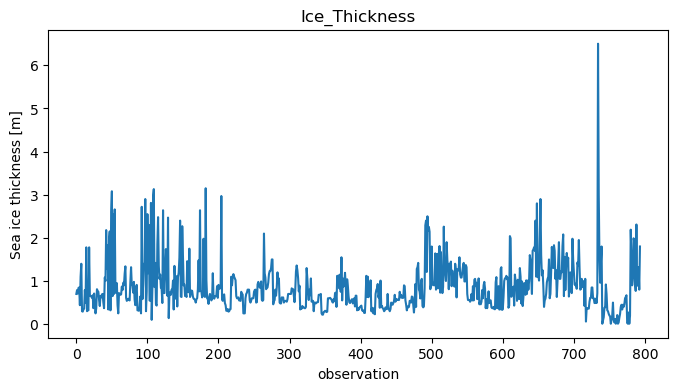

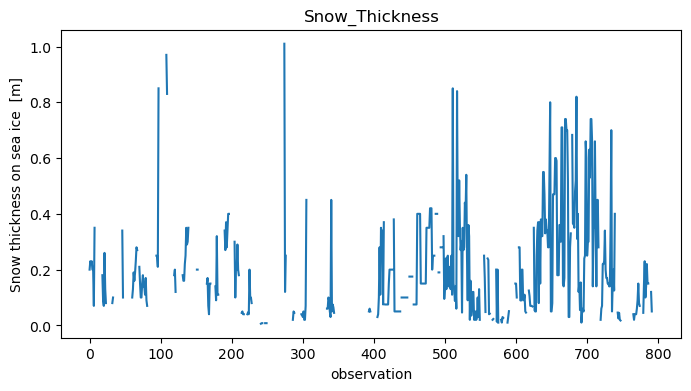

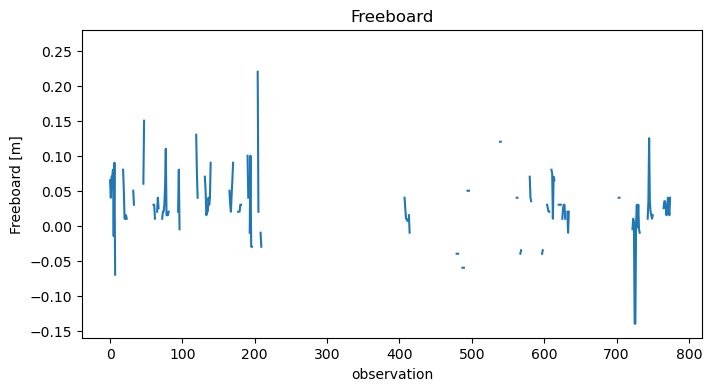

In [14]:
import xarray as xr
import matplotlib.pyplot as plt

ss = xr.open_dataset(r"D:\WORK - UHH\OUTPUT\Antarctic_pack_ice_SOSIMBA_final_v8.nc")


#list all numeric variables
numeric_vars = []

# Data variables
for var in ds.data_vars:
    if np.issubdtype(ss[var].dtype, np.number):
        numeric_vars.append(var)


#plot numeric variable
for var in numeric_vars:
    plt.figure(figsize=(8,4))
    ds[var].where(ss[var] .plot())
    plt.title(var)
    plt.show()

# nc view

In [15]:
!ncdump "D:\WORK - UHH\OUTPUT\Antarctic_pack_ice_SOSIMBA_final_v8.nc"

netcdf D\:\\WORK\ -\ UHH\\OUTPUT\\Antarctic_pack_ice_SOSIMBA_final_v8 {
dimensions:
	observation = 794 ;
variables:
	string Cruise_Field_Campaign(observation) ;
		Cruise_Field_Campaign:long_name = "Cruise or field campaign name" ;
		Cruise_Field_Campaign:coordinates = "time longitude latitude" ;
	string Station_Number(observation) ;
		Station_Number:long_name = "Station number" ;
		Station_Number:standard_name = "station_id" ;
		Station_Number:coordinates = "time longitude latitude" ;
	float Ice_Thickness(observation) ;
		Ice_Thickness:_FillValue = -9.9f ;
		Ice_Thickness:long_name = "Sea ice thickness" ;
		Ice_Thickness:standard_name = "sea_ice_thickness" ;
		Ice_Thickness:units = "m" ;
		Ice_Thickness:coordinates = "time longitude latitude" ;
		Ice_Thickness:cell_methods = "observation: where sea_ice over sea" ;
	float Snow_Thickness(observation) ;
		Snow_Thickness:_FillValue = -9.9f ;
		Snow_Thickness:long_name = "Snow thickness on sea ice " ;
		Snow_Thickness:standard_name = "surfa